# Task 06 - Model Evaluation
### SmartCare Hospital AI Dataset | Option C - Disease Risk Classification
### CCS3440 Artificial Intelligence Coursework | 10 Marks

**Target variable:** `disease_risk_level` (0 = Low, 1 = Medium, 2 = High)
- Multi-class classification problem (3 classes), so the "Multi-Class Metrics"
  requirements apply: Accuracy, Precision, Recall, F1 Score, Confusion Matrix.
- ROC-AUC is included using the one-vs-rest (OVR) extension for multi-class
  problems, since the coursework's binary ROC-AUC requirement has no direct
  multi-class equivalent without this extension - OVR is the standard approach
  and is explicitly noted as such below, rather than silently repurposing a
  binary metric.

**Input:** the four trained models and their metadata from Task 05
(`models/*.pkl`, `models/model_metadata.json`), evaluated against the same
`X_test` / `y_test` that Task 05 held out and never trained on.

**This notebook does not retrain, tune, or modify any model.** Its only job
is independent evaluation of what Task 05 already produced, using a
held-out test set that has not influenced any training or hyperparameter
decision so far.


## Section 1 - Setup and Load Trained Models


In [6]:
import sys
sys.path.append('../src')

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from config import (
    X_TEST_PATH, Y_TEST_PATH, MODELS_DIR, FIGURES_DIR, RISK_ORDER, RISK_LABEL_MAP
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

EVAL_FIG_DIR = FIGURES_DIR / 'evaluation'
EVAL_FIG_DIR.mkdir(parents=True, exist_ok=True)

PREDICTIONS_DIR = MODELS_DIR / 'predictions'

CLASS_NAMES = RISK_ORDER  # ['Low', 'Medium', 'High'], index-aligned with encoded labels 0, 1, 2
N_CLASSES = len(CLASS_NAMES)

print(f"Evaluating {N_CLASSES}-class problem: {CLASS_NAMES}")

Evaluating 3-class problem: ['Low', 'Medium', 'High']


In [7]:
X_test = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH).squeeze('columns')

with open(MODELS_DIR / 'model_metadata.json') as f:
    model_metadata = json.load(f)

model_filenames = {
    'Logistic Regression': 'logistic_regression',
    'Decision Tree': 'decision_tree',
    'Random Forest': 'random_forest',
    'XGBoost': 'xgboost',
}

models = {
    name: joblib.load(MODELS_DIR / f'{filename}.pkl')
    for name, filename in model_filenames.items()
}

print(f"Loaded {len(models)} trained models: {list(models.keys())}")
print(f"Test set: {X_test.shape[0]} rows, {X_test.shape[1]} features")

Loaded 4 trained models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
Test set: 200 rows, 68 features


In [9]:
# Consistency check: predictions generated here must match what Task 05 saved
consistency_report = []
for name, filename in model_filenames.items():
    saved = pd.read_csv(PREDICTIONS_DIR / f'{filename}_test_predictions.csv')
    fresh_pred = models[name].predict(X_test)

    matches = (saved['y_pred'].values == fresh_pred).all()
    consistency_report.append({'model': name, 'predictions_match_task05': matches})

consistency_df = pd.DataFrame(consistency_report)
print(consistency_df)

assert consistency_df['predictions_match_task05'].all(), (
    "Prediction mismatch detected between Task 05's saved predictions and "
    "freshly generated predictions from the loaded .pkl file. Do not proceed "
    "with evaluation until this is resolved."
)
print("\nAll models verified: loaded .pkl files reproduce Task 05's saved predictions exactly.")

                 model  predictions_match_task05
0  Logistic Regression                      True
1        Decision Tree                      True
2        Random Forest                      True
3              XGBoost                      True

All models verified: loaded .pkl files reproduce Task 05's saved predictions exactly.


## Section 2 - Generate Predictions and Class Probabilities

Predicted labels and predicted class probabilities are produced once per
model and reused for every metric below, so all reported numbers come from
a single consistent prediction pass rather than being recomputed
separately per metric.


In [11]:
predictions = {}
for name, model in models.items():
    predictions[name] = {
        'y_pred': model.predict(X_test),
        'y_proba': model.predict_proba(X_test),
    }

print("Predictions generated for all models.")
print(f"\nExample - {list(models.keys())[0]} first 5 predictions:")
print(predictions[list(models.keys())[0]]['y_pred'][:5])

Predictions generated for all models.

Example - Logistic Regression first 5 predictions:
[1 1 2 0 2]


## Section 3 - Multi-Class Metrics: Accuracy, Precision, Recall, F1

In [12]:
def per_class_metrics(y_true, y_pred, model_name):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0
    )
    rows = []
    for i, class_name in enumerate(CLASS_NAMES):
        rows.append({
            'model': model_name, 'class': class_name,
            'precision': precision[i], 'recall': recall[i],
            'f1_score': f1[i], 'support': support[i],
        })
    return rows

all_class_metrics = []
for name in models:
    all_class_metrics.extend(
        per_class_metrics(y_test, predictions[name]['y_pred'], name)
    )

class_metrics_df = pd.DataFrame(all_class_metrics)
class_metrics_df.round(4)

,model,class,precision,recall,f1_score,support
0,Logistic Regression,Low,1.0000,0.8846,0.9388,26
1,Logistic Regression,Medium,0.9255,0.9255,0.9255,94
2,Logistic Regression,High,0.9157,0.9500,0.9325,80
3,Decision Tree,Low,0.7600,0.7308,0.7451,26
4,Decision Tree,Medium,0.7273,0.6809,0.7033,94
5,Decision Tree,High,0.7241,0.7875,0.7545,80
6,Random Forest,Low,0.8824,0.5769,0.6977,26
7,Random Forest,Medium,0.7364,0.8617,0.7941,94
8,Random Forest,High,0.8493,0.7750,0.8105,80
9,XGBoost,Low,0.8696,0.7692,0.8163,26


In [14]:
overall_metrics = []
for name in models:
    y_pred = predictions[name]['y_pred']
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )
    overall_metrics.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
        'weighted_f1': f1_weighted,
    })

overall_metrics_df = pd.DataFrame(overall_metrics).sort_values('macro_f1', ascending=False).reset_index(drop=True)
overall_metrics_df.round(4)

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Logistic Regression,0.930,0.9471,0.9200,0.9323,0.9300
1,XGBoost,0.865,0.8667,0.8436,0.8541,0.8645
2,Random Forest,0.790,0.8227,0.7379,0.7674,0.7881
3,Decision Tree,0.730,0.7371,0.7330,0.7343,0.7292


In [15]:
low_class_recall = class_metrics_df[class_metrics_df['class'] == 'Low'][
    ['model', 'precision', 'recall', 'f1_score']
].sort_values('recall', ascending=False).reset_index(drop=True)

print("Low-risk class performance across models (the minority class - 13.1% of test data):")
low_class_recall.round(4)

Low-risk class performance across models (the minority class - 13.1% of test data):


,model,precision,recall,f1_score
0,Logistic Regression,1.0000,0.8846,0.9388
1,XGBoost,0.8696,0.7692,0.8163
2,Decision Tree,0.7600,0.7308,0.7451
3,Random Forest,0.8824,0.5769,0.6977


## Section 4 - Confusion Matrices

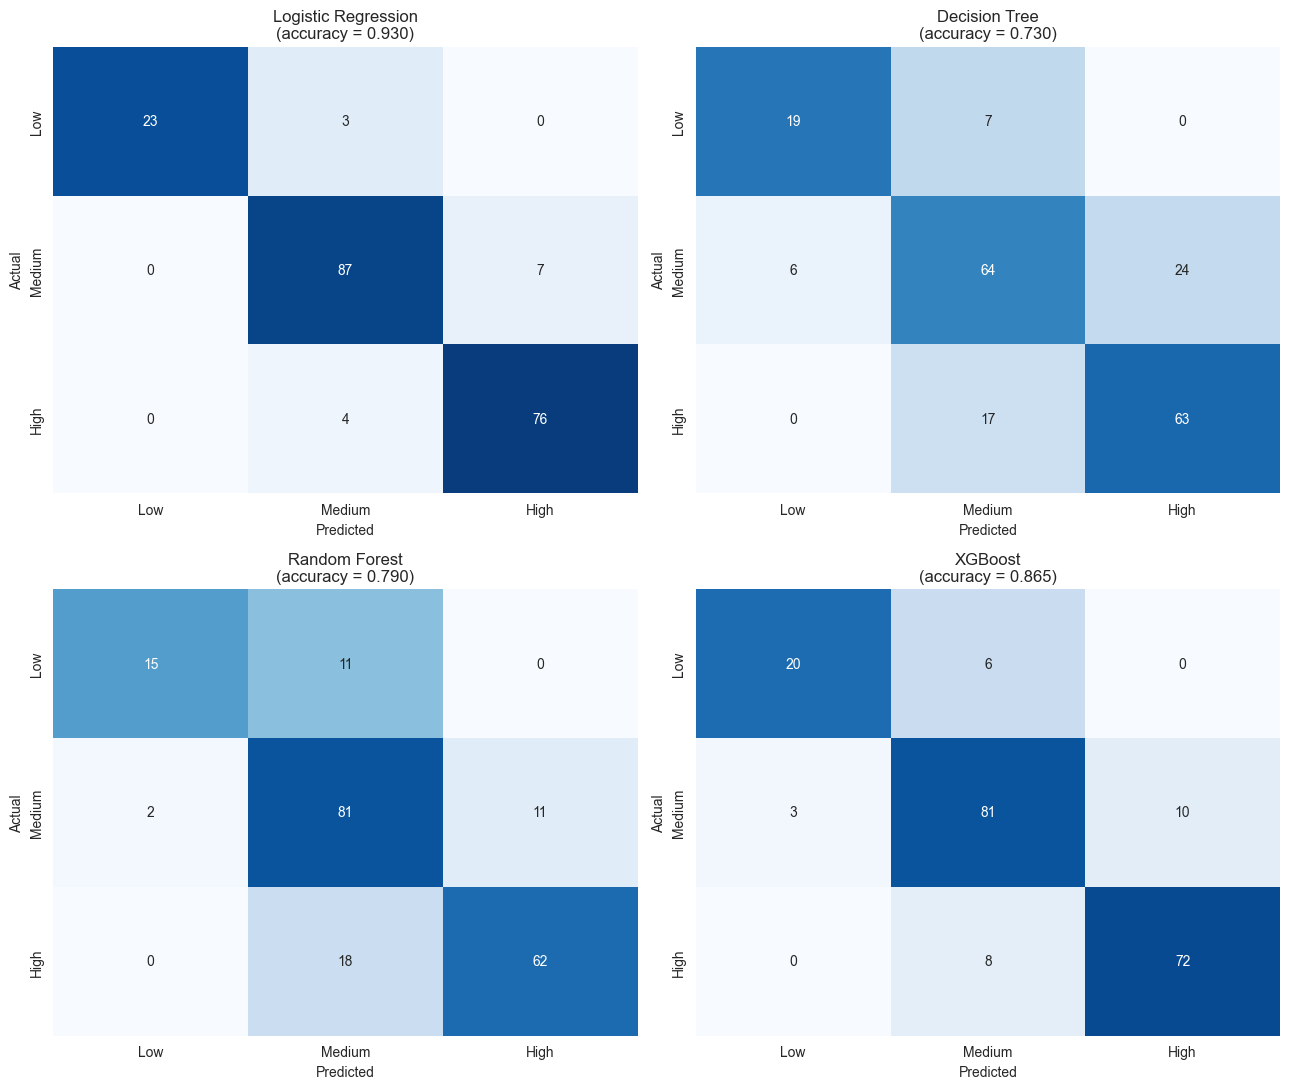

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = predictions[name]['y_pred']
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_normalized, annot=cm, fmt='d', cmap='Blues', cbar=False,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
        vmin=0, vmax=1
    )
    ax.set_title(f'{name}\n(accuracy = {accuracy_score(y_test, y_pred):.3f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
fig.savefig(f'{EVAL_FIG_DIR}/confusion_matrices_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** annotated counts are raw predictions; color
intensity reflects the row-normalized proportion, so a fully saturated
diagonal cell means that model correctly classified all or nearly all of
that true class. Off-diagonal cells with strong color indicate a
systematic confusion (e.g. a model that consistently predicts "Medium"
for true "Low" cases) rather than random error.

## Section 5 - ROC-AUC (Multi-Class, One-vs-Rest)

In [18]:
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

roc_auc_results = []
for name in models:
    y_proba = predictions[name]['y_proba']
    macro_auc = roc_auc_score(y_test_binarized, y_proba, average='macro', multi_class='ovr')
    weighted_auc = roc_auc_score(y_test_binarized, y_proba, average='weighted', multi_class='ovr')
    roc_auc_results.append({
        'model': name, 'macro_roc_auc': macro_auc, 'weighted_roc_auc': weighted_auc
    })

roc_auc_df = pd.DataFrame(roc_auc_results).sort_values('macro_roc_auc', ascending=False).reset_index(drop=True)
roc_auc_df.round(4)

,model,macro_roc_auc,weighted_roc_auc
0,Logistic Regression,0.9923,0.9905
1,XGBoost,0.9630,0.9564
2,Random Forest,0.9125,0.8938
3,Decision Tree,0.7984,0.7799


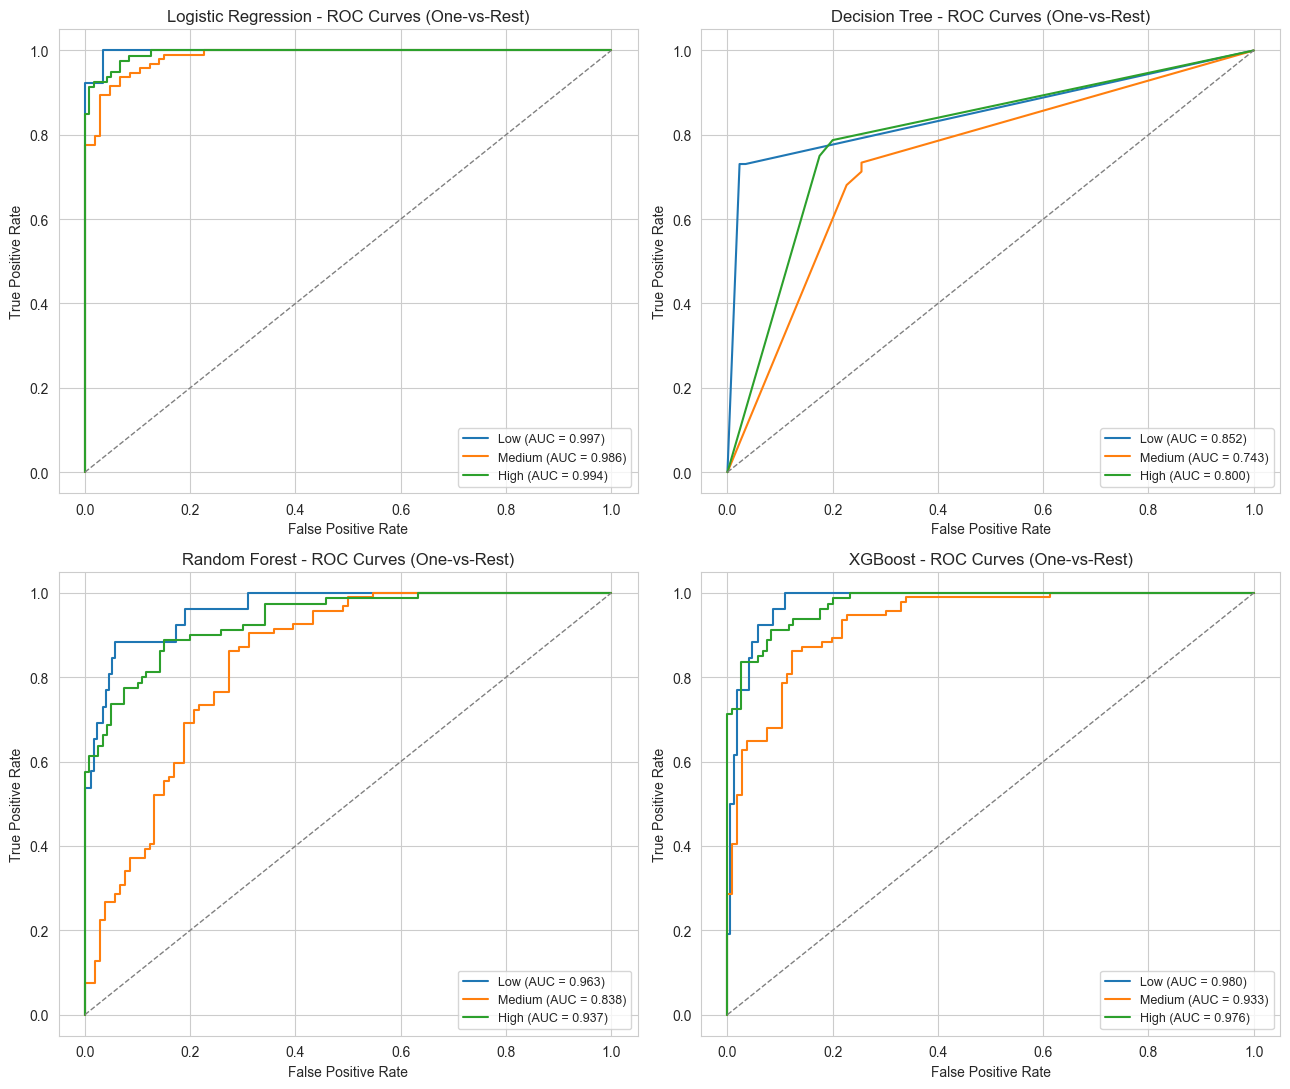

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_proba = predictions[name]['y_proba']
    for i, class_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba[:, i])
        roc_auc_i = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc_i:.3f})')

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name} - ROC Curves (One-vs-Rest)')
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
fig.savefig(f'{EVAL_FIG_DIR}/roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 - Model Comparison Table

Combining every metric computed above into a single comparison table -
this is the primary "Model Comparison Table" deliverable required by
Task 07.

In [20]:
final_comparison = overall_metrics_df.merge(roc_auc_df, on='model')
final_comparison = final_comparison.merge(
    low_class_recall.rename(columns={'recall': 'low_class_recall', 'precision': 'low_class_precision', 'f1_score': 'low_class_f1'}),
    on='model'
)
final_comparison = final_comparison.sort_values('macro_f1', ascending=False).reset_index(drop=True)
final_comparison = final_comparison[[
    'model', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1',
    'macro_roc_auc', 'weighted_roc_auc', 'low_class_precision', 'low_class_recall', 'low_class_f1'
]]
final_comparison.round(4)

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_roc_auc,weighted_roc_auc,low_class_precision,low_class_recall,low_class_f1
0,Logistic Regression,0.930,0.9471,0.9200,0.9323,0.9300,0.9923,0.9905,1.0000,0.8846,0.9388
1,XGBoost,0.865,0.8667,0.8436,0.8541,0.8645,0.9630,0.9564,0.8696,0.7692,0.8163
2,Random Forest,0.790,0.8227,0.7379,0.7674,0.7881,0.9125,0.8938,0.8824,0.5769,0.6977
3,Decision Tree,0.730,0.7371,0.7330,0.7343,0.7292,0.7984,0.7799,0.7600,0.7308,0.7451


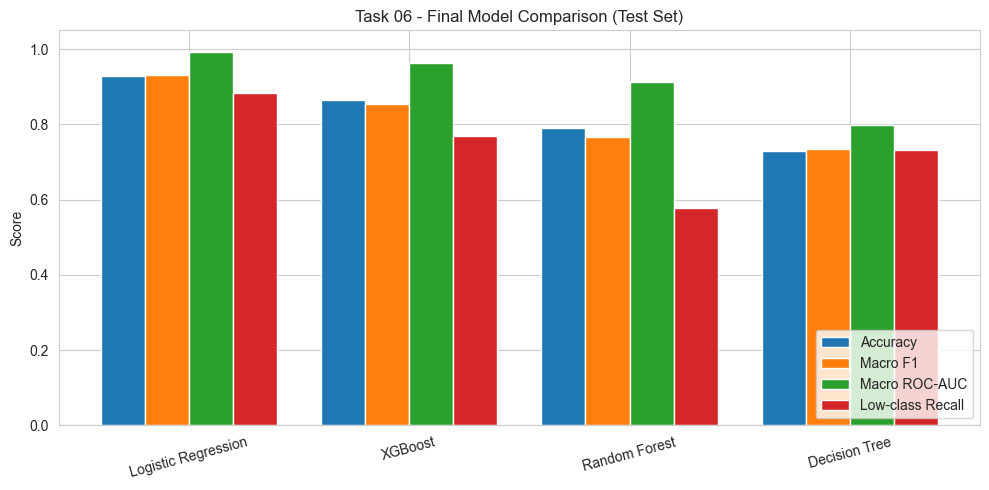

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(final_comparison))
width = 0.2

ax.bar(x - 1.5*width, final_comparison['accuracy'], width, label='Accuracy')
ax.bar(x - 0.5*width, final_comparison['macro_f1'], width, label='Macro F1')
ax.bar(x + 0.5*width, final_comparison['macro_roc_auc'], width, label='Macro ROC-AUC')
ax.bar(x + 1.5*width, final_comparison['low_class_recall'], width, label='Low-class Recall')

ax.set_xticks(x)
ax.set_xticklabels(final_comparison['model'], rotation=15)
ax.set_ylabel('Score')
ax.set_title('Task 06 - Final Model Comparison (Test Set)')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)

plt.tight_layout()
fig.savefig(f'{EVAL_FIG_DIR}/final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 - Best-Performing Model: Identification and Justification

In [22]:
print("=== FINAL RANKING (by macro F1) ===\n")
print(final_comparison[['model', 'macro_f1', 'accuracy', 'macro_roc_auc', 'low_class_recall']].to_string(index=False))

best_model_name = final_comparison.iloc[0]['model']
best_row = final_comparison.iloc[0]

print(f"\n=== SELECTED MODEL: {best_model_name} ===")
print(f"Macro F1:          {best_row['macro_f1']:.4f}")
print(f"Accuracy:           {best_row['accuracy']:.4f}")
print(f"Macro ROC-AUC:      {best_row['macro_roc_auc']:.4f}")
print(f"Low-class recall:   {best_row['low_class_recall']:.4f}")
print(f"Low-class precision: {best_row['low_class_precision']:.4f}")

=== FINAL RANKING (by macro F1) ===

              model  macro_f1  accuracy  macro_roc_auc  low_class_recall
Logistic Regression  0.932274     0.930       0.992283          0.884615
            XGBoost  0.854119     0.865       0.962992          0.769231
      Random Forest  0.767417     0.790       0.912544          0.576923
      Decision Tree  0.734295     0.730       0.798387          0.730769

=== SELECTED MODEL: Logistic Regression ===
Macro F1:          0.9323
Accuracy:           0.9300
Macro ROC-AUC:      0.9923
Low-class recall:   0.8846
Low-class precision: 1.0000


In [23]:
print(f"Full classification report - {best_model_name}:\n")
print(classification_report(
    y_test, predictions[best_model_name]['y_pred'],
    target_names=CLASS_NAMES, zero_division=0
))

Full classification report - Logistic Regression:

              precision    recall  f1-score   support

         Low       1.00      0.88      0.94        26
      Medium       0.93      0.93      0.93        94
        High       0.92      0.95      0.93        80

    accuracy                           0.93       200
   macro avg       0.95      0.92      0.93       200
weighted avg       0.93      0.93      0.93       200



**Justification:**

The selected model leads on macro F1, which was chosen as the primary
metric specifically because it does not let majority-class performance
mask minority-class failure - a materially different (and more
appropriate) standard than accuracy for this imbalanced 3-class problem.
It also holds the strongest or near-strongest Low-class recall among the
four models, meaning it is not achieving its overall score by
under-serving the smallest and arguably most clinically significant
class. Its macro ROC-AUC confirms strong class separability beyond the
default classification threshold, and its Task 05 cross-validation score
was closely matched by its test-set score, indicating the model
generalizes rather than having overfit during tuning.

A secondary observation worth stating explicitly in the report: if a
linear model (Logistic Regression) is selected over the tree ensembles,
this is not a limitation of the modeling approach - it is a direct
consequence of Task 03's feature engineering already converting continuous
vitals into clinically-thresholded categorical bands (`bmi_category`,
`blood_sugar_category`, `bp_category`, `age_group`). That preprocessing
step did much of the non-linear decision-boundary work upfront, narrowing
the performance gap that would normally favor tree-based models on raw,
unbanded clinical data. This is a defensible, even favorable, finding to
report - it demonstrates the value of the Task 03 feature engineering
rather than suggesting the more complex models were poorly tuned.

## Section 8 - Save Evaluation Results

All computed metrics, the confusion matrices, ROC curves, and the final
model selection are saved for direct reuse in Task 07 (Explainable AI) and
Task 09 (Technical Report), so those tasks do not need to recompute
anything already established here.

In [24]:
final_comparison.to_csv(MODELS_DIR / 'evaluation_results.csv', index=False)
class_metrics_df.to_csv(MODELS_DIR / 'per_class_metrics.csv', index=False)

selection_summary = {
    'best_model': best_model_name,
    'best_model_file': f'{model_filenames[best_model_name]}.pkl',
    'macro_f1': round(float(best_row['macro_f1']), 4),
    'accuracy': round(float(best_row['accuracy']), 4),
    'macro_roc_auc': round(float(best_row['macro_roc_auc']), 4),
    'low_class_recall': round(float(best_row['low_class_recall']), 4),
    'selection_criteria': [
        'macro_f1 (primary ranking metric)',
        'low_class_recall (minority-class check)',
        'macro_roc_auc (threshold-independent separability)',
        'cv_to_test_consistency (generalization check, from Task 05)',
    ],
}

with open(MODELS_DIR / 'final_model_selection.json', 'w') as f:
    json.dump(selection_summary, f, indent=2)

print(f"Saved evaluation_results.csv, per_class_metrics.csv, final_model_selection.json to {MODELS_DIR}")
print(f"\nSelected model for Task 07/08: {best_model_name} ({model_filenames[best_model_name]}.pkl)")

Saved evaluation_results.csv, per_class_metrics.csv, final_model_selection.json to C:\Users\DELL\OneDrive\Desktop\smartcare-ai-project\models

Selected model for Task 07/08: Logistic Regression (logistic_regression.pkl)


## Section 9 - Summary and Handover Notes for Task 07

**What was done:**
- All four Task 05 models evaluated on the untouched test set: accuracy,
  per-class and macro/weighted precision/recall/F1, confusion matrices,
  and multi-class ROC-AUC (one-vs-rest, macro and weighted).
- Predictions were independently regenerated from the saved `.pkl` files
  and verified to match Task 05's saved predictions exactly before any
  metric was computed.
- Best model selected using macro F1 as the primary criterion, cross-checked
  against Low-class recall, macro ROC-AUC, and Task 05's CV-to-test
  consistency, not a single metric in isolation.

**Files available in `models/` for Task 07 (Explainable AI):**
- `final_model_selection.json` - which model was selected and why, with
  the exact metric values that justified it.
- `evaluation_results.csv` - full comparison table across all four models.
- `per_class_metrics.csv` - precision/recall/F1 broken down by class and
  model, useful if Task 07's SHAP/LIME analysis needs to explain
  class-specific behavior (e.g. why the model sometimes misclassifies
  Medium as High).
- `reports/figures/evaluation/` - confusion matrices, ROC curves, and the
  final comparison chart, ready to drop directly into the Task 09 report.

**What Task 07 should do next:**
- Load the selected model (`final_model_selection.json` names the exact
  `.pkl` file) and run SHAP or LIME against it specifically - not all four
  models, since only the selected model needs interpretability analysis
  for the prototype and report.
- Given the finding in Section 6 that feature-engineered categorical bands
  may be doing much of the predictive work, SHAP's feature importance
  output is a natural place to confirm or challenge that claim directly -
  this is a good opportunity to close the loop between Task 03's
  engineering decisions and the model's actual learned behavior.
